# Recipe 4 — Set the correlation between two assets

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mamadouyamar/CVineMarketGen/blob/main/examples/recipes/r4_pair_correlation.ipynb)

Two funds you know move together more than a factor model will say: two share classes, a fund and its benchmark, a hedge and its underlying.

<a id="toc"></a>
## Contents

| | |
|---|---|
| **[1. The base](#s1)** | eight funds, six factors, nothing imposed |
| **[2. What is free and what is not](#s2)** | the eligible range |
| **[3. What you give](#s3)** | one row in the pairs sheet |
| **[4. What the simulator does](#s4)** | the residual correlation |
| **[5. Check](#s5)** | the correlation in the scenarios |
| **[6. Outside the range](#s6)** | the two refusals, and what to do instead |
| **[Where to look next](#next)** | the other recipes and the derivations |

---

<a id="s1"></a>
## 1. The base

<sub>[back to contents](#toc)</sub>

Eight funds, six factors, nothing imposed.

The base is `examples/inputs/recipe_base.xlsx`: eight funds, six factors, and
not one number imposed. Every mean, volatility, shape and beta below comes
from the monthly histories since June 2007.

`tags` says which factors each class may load on. `fit` means regressed, an
empty cell means a beta of zero, and the four other sheets are empty.

ETF returns read from cache /Users/mamadouthioub/Desktop/CopulaGenerator/CVineMarketGen/data/etf_cache_universe.csv: 232 months, 2007-06 to 2026-09
factor data read from cache /Users/mamadouthioub/Desktop/CopulaGenerator/CVineMarketGen/data/factors_cache.csv: 244 months, 2006-04 to 2026-07
FactorMarket(8 assets on 6 factors, generator='fleishman', 0 assets without history, 0 factors without history)


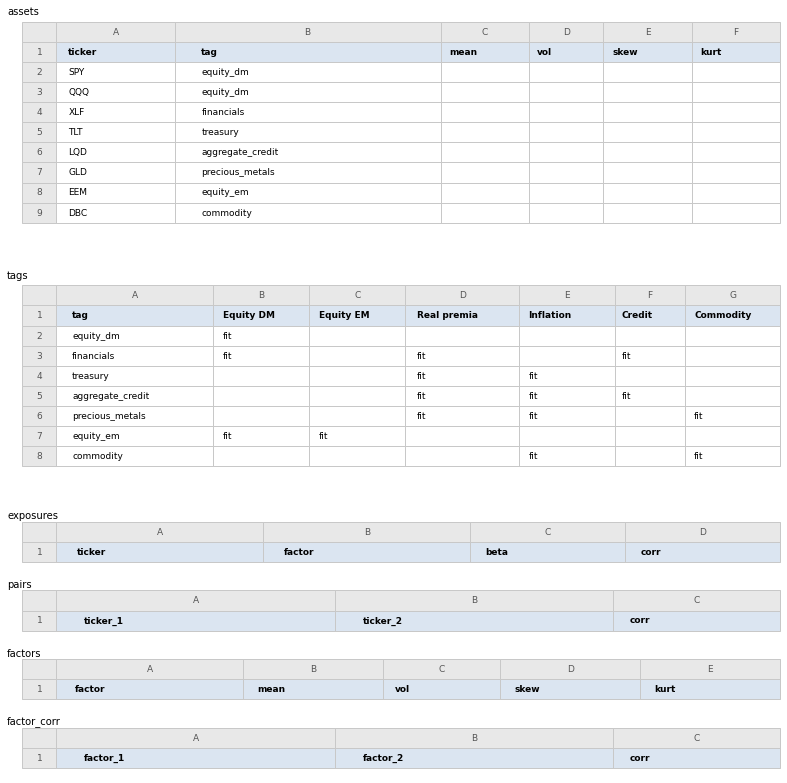

In [1]:
import os, sys, warnings
import numpy as np
import pandas as pd
warnings.filterwarnings("ignore")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30); pd.set_option("display.max_colwidth", 200)

ROOT = os.getcwd()                                   # the repo root, from wherever the notebook is opened
while not os.path.isdir(os.path.join(ROOT, "cvinemarketgen")) and os.path.dirname(ROOT) != ROOT:
    ROOT = os.path.dirname(ROOT)
sys.path.insert(0, ROOT)
try:
    import cvinemarketgen
except ImportError:                                  # Google Colab
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/mamadouyamar/CVineMarketGen.git", "openpyxl"], check=True)
    import cvinemarketgen
from cvinemarketgen import load_etf_monthly, load_factor_data, MarketSpec, FactorMarket, show_workbook, show_change, show_sheet

FACTORS = ["Equity DM", "Equity EM", "Real premia", "Inflation", "Credit", "Commodity"]
A = lambda m: m * 1200                               # monthly mean -> percent a year
V = lambda v: v * np.sqrt(12) * 100                  # monthly vol  -> percent a year
spec = MarketSpec.read(os.path.join(ROOT, "examples", "inputs", "recipe_base.xlsx"))
tick = list(spec.assets["ticker"])
R = load_etf_monthly(tick, start="2007-04", cache=os.path.join(ROOT, "data", "etf_cache_universe.csv"))[tick]
F = load_factor_data(cache=os.path.join(ROOT, "data", "factors_cache.csv"))[FACTORS]
idx = R.index.intersection(F.index); R, F = R.loc[idx], F.loc[idx]
sim = FactorMarket(R, F, spec, generator="fleishman").fit()
print(sim)
show_workbook(spec, max_rows=8)

Eight assets on six factors, all from the histories. The generator is
Fleishman, which fits in a second; notebook 03 uses the C-vine, which takes
the tail dependence of the factors with it.

---

<a id="s2"></a>
## 2. What is free and what is not

<sub>[back to contents](#toc)</sub>

The eligible range.

Two assets are correlated through their factors and through their residuals:

$$
\rho_{ij} = \underbrace{\frac{\boldsymbol\beta_i' \boldsymbol\Sigma_f \boldsymbol\beta_j}{\sigma_i \sigma_j}}_{\rho_{ij}^{\text{sys}}}
          + \rho_{e,ij} \sqrt{(1 - R_i^2)(1 - R_j^2)} .
$$

The betas are already fixed, so only $\rho_{e,ij}$ is free, and it lives in
$[-1, 1]$. The reachable correlations are therefore

$$
\rho_{ij} \in \Big[\rho_{ij}^{\text{sys}} - \sqrt{(1 - R_i^2)(1 - R_j^2)},\;
                   \rho_{ij}^{\text{sys}} + \sqrt{(1 - R_i^2)(1 - R_j^2)}\Big] ,
$$

and the residual correlation the target needs is

$$
\rho_{e,ij} = \frac{\rho_{ij}\,\sigma_i \sigma_j - \boldsymbol\beta_i' \boldsymbol\Sigma_f \boldsymbol\beta_j}
                   {\sigma_{e,i}\, \sigma_{e,j}} .
$$

Well-explained assets have little room; assets the factors barely touch have
almost the whole interval.

In [2]:
pd.DataFrame({"R2": sim.model.r2, "unexplained share 1 - R2": 1 - sim.model.r2, "half-width of a pair's range": np.sqrt(1 - sim.model.r2)}).round(2)

,R2,unexplained share 1 - R2,half-width of a pair's range
SPY,0.93,0.07,0.26
QQQ,0.77,0.23,0.48
XLF,0.73,0.27,0.52
TLT,0.89,0.11,0.34
LQD,0.75,0.25,0.50
GLD,0.31,0.69,0.83
EEM,0.94,0.06,0.24
DBC,1.00,0.00,0.03


A pair's half-width is the product of the two in the last column: 0.12 for
SPY and QQQ, 0.28 for GLD and TLT.

---

<a id="s3"></a>
## 3. What you give

<sub>[back to contents](#toc)</sub>

One row in the pairs sheet.

A correlation of 0.95 between SPY and QQQ, whose history shows 0.92.

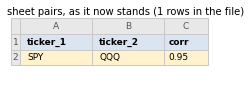

In [3]:
pair = {"ticker_1": "SPY", "ticker_2": "QQQ", "corr": 0.95}
spec_4 = spec.add("pairs", pair)
show_change(spec_4, "pairs", pair)

---

<a id="s4"></a>
## 4. What the simulator does

<sub>[back to contents](#toc)</sub>

The residual correlation.

The pair report shows the range, the target in it, and the residual
correlation used.

In [4]:
sim_4 = sim.with_spec(spec_4)
sim_4.pair_report.round(3)

,,R2_i,R2_j,range high,range low,residual correlation,systematic,target
asset i,asset j,,,,,,,
SPY,QQQ,0.933,0.774,0.973,0.727,0.815,0.85,0.95


The betas alone already give 0.85, and the residuals can move that by 0.12
either way, so 0.95 is inside the range. It is bought with a residual
correlation of 0.815, which is what the two residuals are made to share.

---

<a id="s5"></a>
## 5. Check

<sub>[back to contents](#toc)</sub>

The correlation in the scenarios.

Simulate and measure the pair, against the target and against the sample.

In [5]:
X4 = sim_4.simulate(20000, seed=6); X0 = sim.simulate(20000, seed=6)
pd.DataFrame({"correlation": [float(sim_4.pair_report["target"]), X4["SPY"].corr(X4["QQQ"]), X0["SPY"].corr(X0["QQQ"]), R["SPY"].corr(R["QQQ"])]},
             index=["asked", "simulated", "simulated without the row", "in the sample"]).round(3)

,correlation
asked,0.950
simulated,0.950
simulated without the row,0.850
in the sample,0.915


The row is delivered: 0.950 simulated against 0.950 asked, where the same
simulator without the row gives 0.850. The sample sits between the two at
0.915.

---

<a id="s6"></a>
## 6. Outside the range

<sub>[back to contents](#toc)</sub>

The two refusals, and what to do instead.

A target below the range, and one above it.

In [6]:
for i, j, rho in [("SPY", "QQQ", 0.50), ("GLD", "TLT", 0.60)]:
    try:
        sim.with_spec(spec.add("pairs", {"ticker_1": i, "ticker_2": j, "corr": rho})); print(f"{i}/{j} {rho} -> accepted\n")
    except ValueError as err:
        print(f"{i}/{j} {rho} -> refused:", err, "\n")

SPY/QQQ 0.5 -> refused: pair_correlations: (SPY, QQQ): target 0.500 is outside the eligible range [0.727, 0.973] = systematic correlation 0.850 +/- sqrt((1 - R2_i)(1 - R2_j)) with R2 0.93 and 0.77; only the residual covariance is free 

GLD/TLT 0.6 -> refused: pair_correlations: (GLD, TLT): target 0.600 is outside the eligible range [0.009, 0.572] = systematic correlation 0.290 +/- sqrt((1 - R2_i)(1 - R2_j)) with R2 0.31 and 0.89; only the residual covariance is free 



Both are refused, with the range and the two $R^2$ that produced it. The range
is narrow exactly where the factors explain the two assets well, so a target
outside it is a statement about the betas: change those, and the systematic
correlation itself moves.

---

<a id="next"></a>
## Where to look next

<sub>[back to contents](#toc)</sub>

The whole universe in one file, fitted, checked and written out:
[notebook 03](../03_many_assets_factors.ipynb). The derivations, the feasible
shapes and the bounds: the methods note, `docs/methods-note.pdf`.

The other levers:

- [what an asset loads on](r1_exposures.ipynb)
- [a fund with no history](r2_asset_without_history.ipynb)
- [an asset's mean, volatility and shape](r3_asset_targets.ipynb)
- [a view on a factor](r5_factor_views.ipynb)
- [a factor with no history](r6_factor_without_history.ipynb)